In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

In [2]:
# Load Dataset
df = pd.read_csv("penguins.csv")
df = df.dropna()

print(df.shape)
df.head()

(332, 5)


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181,3750,MALE
1,39.5,17.4,186,3800,FEMALE
2,40.3,18.0,195,3250,FEMALE
3,36.7,19.3,193,3450,FEMALE
4,39.3,20.6,190,3650,MALE


In [3]:
# Encode target column (sex)
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

# Features and Target
X = df.drop("sex", axis=1)
y = df["sex"]

X.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181,3750
1,39.5,17.4,186,3800
2,40.3,18.0,195,3250
3,36.7,19.3,193,3450
4,39.3,20.6,190,3650


In [4]:
# Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Apply PCA for dimensionality reduction (4D to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
# Variance ratio
print("Explained Variance Ratio :", pca.explained_variance_ratio_)
print("Total Variance Covered :", round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Explained Variance Ratio : [0.68713344 0.19641564]
Total Variance Covered : 88.35 %


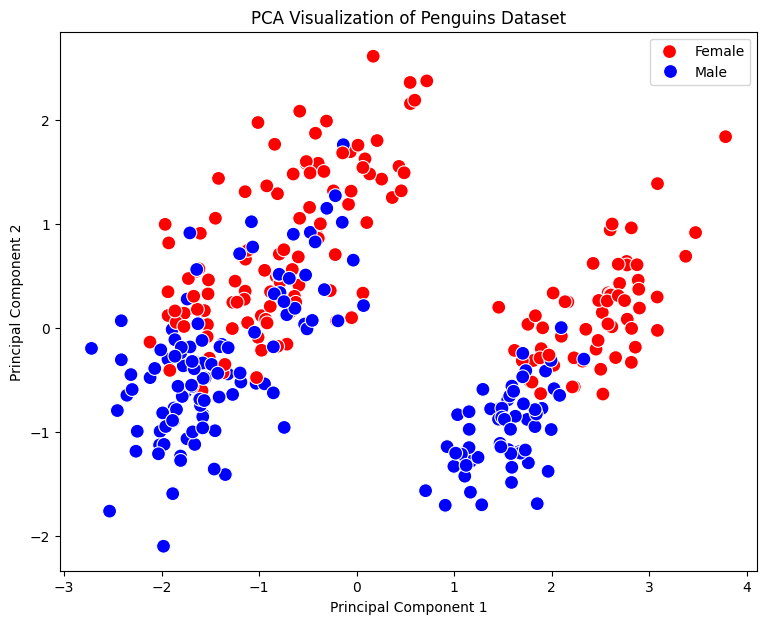

In [7]:
# Visualize PCA result
plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette={0:"blue", 1:"red"},
    s=100
)

plt.title("PCA Visualization of Penguins Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(labels=["Female", "Male"])
plt.show()

In [8]:
# Print the loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

loadings

,PC1,PC2
culmen_length_mm,0.453174,0.604990
culmen_depth_mm,-0.398518,0.792959
flipper_length_mm,0.576880,0.003798
body_mass_g,0.550478,0.072032


In [9]:
# Train KNN model on PCA data
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_pca, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [10]:
# Create custom input data
custom_data = pd.DataFrame([{
    "culmen_length_mm": 45.2,
    "culmen_depth_mm": 17.1,
    "flipper_length_mm": 210,
    "body_mass_g": 4500
}])

# Scale and transform custom data using PCA
custom_scaled = scaler.transform(custom_data)
custom_pca = pca.transform(custom_scaled)

print("PC1 =", round(custom_pca[0][0], 3))
print("PC2 =", round(custom_pca[0][1], 3))

PC1 = 0.681
PC2 = 0.138


In [11]:
# Predict class of custom input
pred = knn_pca.predict(custom_pca)[0]

print("Predicted Class :", le.inverse_transform([pred])[0])

Predicted Class : MALE


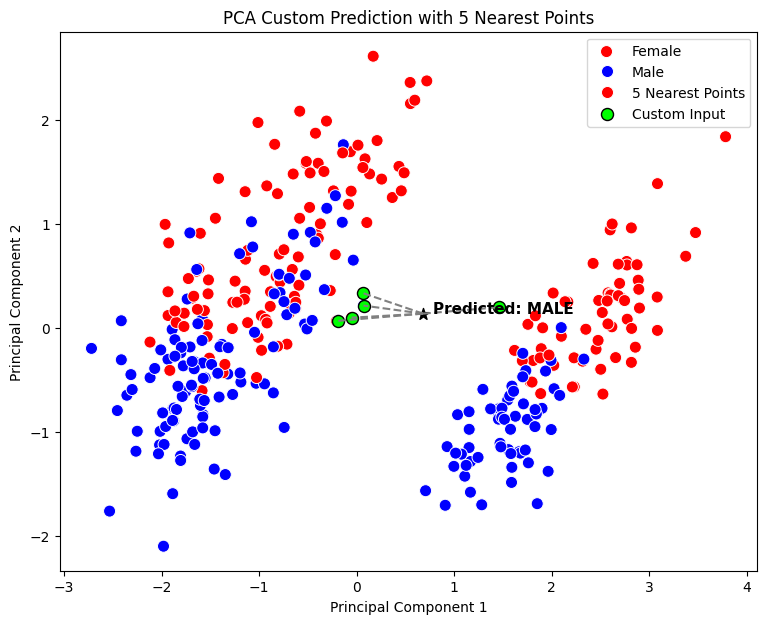

In [12]:
# Plot dataset with custom point and 5 nearest neighbors
# Find 5 nearest points in PCA space
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)

distances, indices = nn.kneighbors(custom_pca)

plt.figure(figsize=(9,7))

# Plot original PCA points
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette={0:"blue", 1:"red"},
    s=75
)

# Plot nearest neighbors
plt.scatter(
    X_pca[indices[0],0],
    X_pca[indices[0],1],
    c="lime",
    s=75,
    edgecolors="black",
    label="5 Nearest Points"
)

# Plot custom point
plt.scatter(
    custom_pca[:,0],
    custom_pca[:,1],
    c="black",
    marker="*",
    s=75,
    label="Custom Input"
)

# Draw lines from custom point to neighbors
for idx in indices[0]:
    plt.plot(
        [custom_pca[0,0], X_pca[idx,0]],
        [custom_pca[0,1], X_pca[idx,1]],
        '--',
        color='gray',
        linewidth=1.5
    )

# Predicted class text
plt.text(
    custom_pca[0][0] + 0.1,
    custom_pca[0][1],
    f"Predicted: {le.inverse_transform([pred])[0]}",
    fontsize=11,
    weight="bold"
)

plt.title("PCA Custom Prediction with 5 Nearest Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(labels=["Female", "Male", "5 Nearest Points", "Custom Input"])
plt.show()